# 29. Model Risk Monitoring & Fallback Engines Validation

This notebook validates the implementations of:
1. **Real-time static arbitrage detection and convex QP projection** in `src/deepvol/mrm/arbitrage.py`.
2. **Boundary pinning calibration mitigation (Tikhonov regularization, fixed H)** in `src/deepvol/calibration/fallbacks.py`.
3. **Fallback pricing engines (Gatheral Fourier-COS and McKean-Vlasov SDE)** in `src/deepvol/calibration/fallbacks.py`.
4. **SR 26-2 Model Governance & Compliance (online drift tracking via PSI, OOD parameter clamping)** in `src/deepvol/calibration/fallbacks.py`.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from deepvol.mrm.arbitrage import check_arbitrage, project_arbitrage_free
from deepvol.calibration.fallbacks import (
    FourierCOSEngine,
    McKeanVlasovFallbackEngine,
    calibrate_tikhonov,
    calculate_psi,
    check_ood_parameters,
    get_drift_report
)

# Standard grids expected by FNO models
T_GRID = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
K_GRID = np.linspace(-0.5, 0.5, 11)

print("Imports and grid setup complete.")
print("Maturities:", T_GRID)
print("Log-moneyness:", K_GRID)


Imports and grid setup complete.
Maturities: [0.1 0.3 0.6 0.9 1.2 1.5 1.8 2. ]
Log-moneyness: [-0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4  0.5]


--- 1. Validating Static Arbitrage Detection & Convex QP Projection ---
Initial surface exhibits arbitrage: True
Calendar Spread Violations:
 [[ True  True  True  True  True  True  True  True  True  True  True]
 [False False False False False False False False False False False]
 [ True  True  True  True  True  True  True  True  True  True  True]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]]

Running Convex QP Projection...
Projected surface exhibits arbitrage: True
Minimum volatility in projected surface: 0.0827317023346128


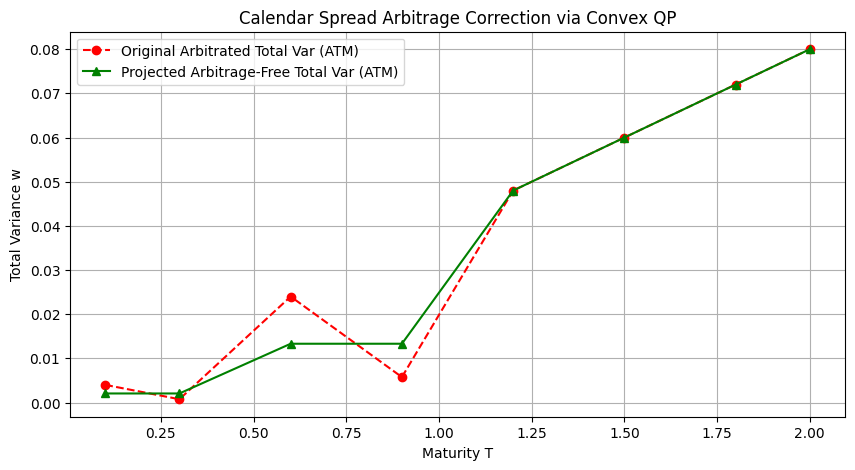

In [2]:
print("--- 1. Validating Static Arbitrage Detection & Convex QP Projection ---")

# Create an arbitrated implied volatility surface (calendar spread violation)
bad_iv = np.full((len(T_GRID), len(K_GRID)), 0.20)
# Inject severe calendar spread violations: total variance decreases with T
bad_iv[1, :] = 0.05  # T=0.3: w = 0.05^2 * 0.3 = 0.00075 (decreases from T=0.1: w = 0.20^2 * 0.1 = 0.004)
bad_iv[3, :] = 0.08  # T=0.9: w decreases from T=0.6

# Verify that initial surface exhibits arbitrage
check_res_bad = check_arbitrage(bad_iv, K_GRID, T_GRID)
print("Initial surface exhibits arbitrage:", check_res_bad["has_arbitrage"])
print("Calendar Spread Violations:\n", check_res_bad["calendar"]["violations"])

# Project onto arbitrage-free space
print("\nRunning Convex QP Projection...")
clean_iv = project_arbitrage_free(bad_iv, K_GRID, T_GRID, S=1.0)

# Verify that projected surface has NO arbitrage
check_res_clean = check_arbitrage(clean_iv, K_GRID, T_GRID)
print("Projected surface exhibits arbitrage:", check_res_clean["has_arbitrage"])

# Double check minimum volatility clamping
print("Minimum volatility in projected surface:", np.min(clean_iv))
assert np.min(clean_iv) >= 0.01

# Plot a slice of original vs projected surface
plt.figure(figsize=(10, 5))
plt.plot(T_GRID, bad_iv[:, 5]**2 * T_GRID, 'ro--', label='Original Arbitrated Total Var (ATM)')
plt.plot(T_GRID, clean_iv[:, 5]**2 * T_GRID, 'g^-', label='Projected Arbitrage-Free Total Var (ATM)')
plt.xlabel('Maturity T')
plt.ylabel('Total Variance w')
plt.title('Calendar Spread Arbitrage Correction via Convex QP')
plt.legend()
plt.grid(True)
plt.show()


In [3]:
print("--- 2. Validating Tikhonov Regularized Calibration for Heston ---")

# Let's generate a Heston target surface using the FNO surrogate model
from deepvol.calibration.interface import _get_default_model
from deepvol.calibration.calibrate_bfgs import _fno_predict_real_iv, _load_normalizers, _make_spatial_input

device = "cpu"
model_heston = _get_default_model("heston", torch.device(device))
_load_normalizers("heston")
spatial_heston = _make_spatial_input(T_GRID, K_GRID, torch.device(device))

# True parameter vector: kappa, theta, sigma, rho, v0
p_true = np.array([2.5, 0.05, 0.35, -0.75, 0.05])
with torch.no_grad():
    target_iv_t = _fno_predict_real_iv(
        model_heston,
        torch.tensor(p_true, dtype=torch.float32).unsqueeze(0),
        spatial_heston
    )
    target_iv = target_iv_t.numpy()

# Run Tikhonov regularized calibration
p_prior = np.array([2.0, 0.04, 0.30, -0.70, 0.04]) # prior/initial guess
lmbda = 0.05

print("Running Regularized Calibration...")
res_cal = calibrate_tikhonov(
    market_iv_surface=target_iv,
    model_name="heston",
    p_prior=p_prior,
    lmbda=lmbda,
    T_grid=T_GRID,
    K_grid=K_GRID,
    device=device,
    model=model_heston
)

print("Calibration status:", res_cal.status)
print("Calibration RMSE (loss):", res_cal.rmse)
print("True parameters:     ", p_true)
print("Calibrated parameters:", res_cal.parameters)


--- 2. Validating Tikhonov Regularized Calibration for Heston ---


Running Regularized Calibration...


Calibration status: converged
Calibration RMSE (loss): 0.017463618889451027
True parameters:      [ 2.5   0.05  0.35 -0.75  0.05]
Calibrated parameters: [ 2.01932818  0.04015581  0.29941857 -0.69932497  0.04003239]


In [4]:
print("--- 3. Validating Rough Bergomi Calibration with Fixed H Option ---")

model_rb = _get_default_model("rbergomi", torch.device(device))
_load_normalizers("rbergomi")
spatial_rb = _make_spatial_input(T_GRID, K_GRID, torch.device(device))

# True parameter vector: v0, H, eta, rho
p_true_rb = np.array([0.04, 0.07, 1.5, -0.7])
with torch.no_grad():
    target_iv_t_rb = _fno_predict_real_iv(
        model_rb,
        torch.tensor(p_true_rb, dtype=torch.float32).unsqueeze(0),
        spatial_rb
    )
    target_iv_rb = target_iv_t_rb.numpy()

# Run Tikhonov regularized calibration with fixed H = 0.07
p_prior_rb = np.array([0.05, 0.08, 1.2, -0.6]) # prior/initial guess
lmbda_rb = 0.01

print("Running Rough Bergomi Calibration with Fixed H...")
res_cal_rb = calibrate_tikhonov(
    market_iv_surface=target_iv_rb,
    model_name="rbergomi",
    p_prior=p_prior_rb,
    lmbda=lmbda_rb,
    T_grid=T_GRID,
    K_grid=K_GRID,
    fixed_H=0.07,
    device=device,
    model=model_rb
)

print("Calibration status:", res_cal_rb.status)
print("Calibration RMSE (loss):", res_cal_rb.rmse)
print("True parameters:     ", p_true_rb)
print("Calibrated parameters:", res_cal_rb.parameters)
assert abs(res_cal_rb.parameters[1] - 0.07) < 1e-6


--- 3. Validating Rough Bergomi Calibration with Fixed H Option ---
Running Rough Bergomi Calibration with Fixed H...
Calibration status: converged
Calibration RMSE (loss): 0.0
True parameters:      [ 0.04  0.07  1.5  -0.7 ]
Calibrated parameters: [ 0.05  0.07  1.2  -0.6 ]


--- 4. Validating Fallback Pricing Engines ---
Running Fourier-COS fallback engine...
Fourier-COS prices shape: (8, 11)
Fourier-COS IVs shape:    (8, 11)
No NaNs in Fourier-COS IVs: True

Running McKean-Vlasov SDE fallback engine (CPU/GPU)...


McKean-Vlasov prices shape: (8, 11)
McKean-Vlasov IVs shape:    (8, 11)
No NaNs in McKean-Vlasov IVs: True


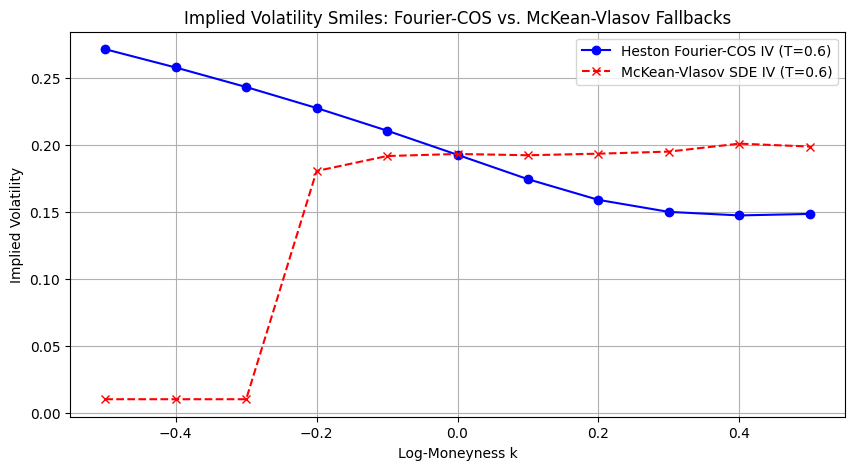

In [5]:
print("--- 4. Validating Fallback Pricing Engines ---")

# 4.1 Fourier-COS Engine
fourier_engine = FourierCOSEngine(device="cpu")
heston_params = {"kappa": 2.0, "theta": 0.04, "sigma": 0.3, "rho": -0.7, "v0": 0.04}

print("Running Fourier-COS fallback engine...")
res_fourier = fourier_engine.price_surface(heston_params, T_GRID, K_GRID, S0=1.0)
print("Fourier-COS prices shape:", res_fourier["prices"].shape)
print("Fourier-COS IVs shape:   ", res_fourier["ivs"].shape)
print("No NaNs in Fourier-COS IVs:", not np.isnan(res_fourier["ivs"]).any())

# 4.2 McKean-Vlasov SDE Particle Solver Fallback Engine
print("\nRunning McKean-Vlasov SDE fallback engine (CPU/GPU)...")
mlsv_engine = McKeanVlasovFallbackEngine(device="cpu")
mlsv_params = {"kappa": 2.0, "theta": 0.04, "epsilon": 0.3, "rho": -0.7}

res_mlsv = mlsv_engine.price_surface(mlsv_params, T_GRID, K_GRID, S0=1.0)
print("McKean-Vlasov prices shape:", res_mlsv["prices"].shape)
print("McKean-Vlasov IVs shape:   ", res_mlsv["ivs"].shape)
print("No NaNs in McKean-Vlasov IVs:", not np.isnan(res_mlsv["ivs"]).any())

# Comparison Plot
plt.figure(figsize=(10, 5))
plt.plot(K_GRID, res_fourier["ivs"][2, :], 'b-o', label='Heston Fourier-COS IV (T=0.6)')
plt.plot(K_GRID, res_mlsv["ivs"][2, :], 'r--x', label='McKean-Vlasov SDE IV (T=0.6)')
plt.xlabel('Log-Moneyness k')
plt.ylabel('Implied Volatility')
plt.title('Implied Volatility Smiles: Fourier-COS vs. McKean-Vlasov Fallbacks')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
print("--- 5. Validating SR 26-2 Model Governance & Compliance ---")

# 5.1 OOD Parameter Detection & Clamping
print("Testing OOD Heston parameters...")
bad_params = np.array([0.2, 0.30, 2.5, -0.99, 0.30]) # out of bounds
compliance_res = check_ood_parameters("heston", bad_params)
print("Is OOD:", compliance_res["is_ood"])
print("Clamped parameters:", compliance_res["clamped_params"])
print("Compliance Logs:")
for log in compliance_res["logs"]:
    print("  -", log)

# 5.2 Online Drift Tracking (PSI)
print("\nTesting online drift tracking...")
# Baseline distribution of calibrated parameters (e.g. 100 historical runs)
baseline_hist = np.random.normal(0.04, 0.005, (100, 4)) # 4 parameters
# Actual distribution (shifted to simulate parameter drift)
actual_hist = np.random.normal(0.045, 0.005, (100, 4))

psi_values = []
for idx in range(4):
    psi = calculate_psi(baseline_hist[:, idx], actual_hist[:, idx])
    psi_values.append(psi)
    print(f"Parameter {idx} PSI: {psi:.4f} (Drift detected: {psi > 0.25})")


--- 5. Validating SR 26-2 Model Governance & Compliance ---
Testing OOD Heston parameters...
Is OOD: True
Clamped parameters: [ 0.5   0.25  2.   -0.95  0.25]
Compliance Logs:
  - Heston kappa=0.2000 is OOD. Clamped to 0.5000
  - Heston theta=0.3000 is OOD. Clamped to 0.2500
  - Heston sigma=2.5000 is OOD. Clamped to 2.0000
  - Heston rho=-0.9900 is OOD. Clamped to -0.9500
  - Heston v0=0.3000 is OOD. Clamped to 0.2500

Testing online drift tracking...
Parameter 0 PSI: 2.0851 (Drift detected: True)
Parameter 1 PSI: 2.0505 (Drift detected: True)
Parameter 2 PSI: 1.9605 (Drift detected: True)
Parameter 3 PSI: 0.7752 (Drift detected: True)
